In [ ]:
# Deep Learning-Based OCR for Medical Prescription Recognition

**Team Members:**  
Baradan Mainali  
Suman Khanal  

This notebook implements a CRNN-based OCR pipeline for recognizing text from synthetic medical prescription images.
 The workflow includes data preparation, vocabulary construction, dataset creation, model training with CTC loss, 
evaluation using CER and WER, and qualitative prediction examples.

In [6]:
# Imports + Device
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from jiwer import wer

device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [7]:
# Load + Prepare data 
# To make the OCR task more trainable, the target text is limited to medicine name + dosage.
labels_path = "synthetic_prescription_dataset/labels.csv"
images_dir = "synthetic_prescription_dataset/images"

labels_df = pd.read_csv(labels_path)

for col in ["medicine", "dosage"]:
    labels_df[col] = labels_df[col].astype(str).str.strip()

# Shorter OCR target: medicine + dosage only
labels_df["line_text"] = (
    labels_df["medicine"] + " " + labels_df["dosage"]
)

grouped_df = labels_df.groupby("image")["line_text"].apply(lambda x: " ".join(x)).reset_index()

grouped_df["text_length"] = grouped_df["line_text"].apply(len)

print(grouped_df.head())
print("Total samples before filtering:", len(grouped_df))
print(grouped_df["text_length"].describe())

# Keep moderate-length samples
grouped_df = grouped_df[grouped_df["text_length"] <= 120].reset_index(drop=True)

print("Total samples after filtering:", len(grouped_df))
print(grouped_df["text_length"].describe())

                   image                                          line_text  \
0     prescription_0.png  Metformin 500mg Azithromycin 200mg Cetirizine ...   
1     prescription_1.png  Metformin 10mg Pantoprazole 40mg Azithromycin ...   
2    prescription_10.png  Paracetamol 500mg Amoxicillin 250mg Diclofenac...   
3   prescription_100.png  Atorvastatin 250mg Omeprazole 500mg Ibuprofen ...   
4  prescription_1000.png  Azithromycin 40mg Diclofenac 250mg Atorvastati...   

   text_length  
0          104  
1          115  
2          119  
3          107  
4           85  
Total samples before filtering: 2000
count    2000.0000
mean      119.0360
std        27.2362
min        61.0000
25%       100.0000
50%       119.0000
75%       138.0000
max       180.0000
Name: text_length, dtype: float64
Total samples after filtering: 1095
count    1095.000000
mean       98.880365
std        16.101975
min        61.000000
25%        86.000000
50%       101.000000
75%       115.000000
max       120.000

In [9]:
# Vocabulary + Helper Functions
all_text = " ".join(grouped_df["line_text"].tolist())
vocab = sorted(list(set(all_text)))

char_to_idx = {char: idx + 1 for idx, char in enumerate(vocab)}
idx_to_char = {idx + 1: char for idx, char in enumerate(vocab)}
blank_idx = 0

def encode_text(text):
    return [char_to_idx[c] for c in text]

def decode_prediction(indices):
    result = []
    prev = None
    for i in indices:
        i = int(i)
        if i != blank_idx and i != prev:
            result.append(idx_to_char.get(i, ""))
        prev = i
    return "".join(result)

def char_error_rate(gt, pred):
    if len(gt) == 0:
        return 0
    m, n = len(gt), len(pred)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if gt[i-1] == pred[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    return dp[m][n] / m

print("Vocab size:", len(vocab))

Vocab size: 34


In [10]:
# Dataset + Dataloader
class OCRDataset(Dataset):
    def __init__(self, df, image_dir):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image"])

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (512, 64))  # wider image
        image = image / 255.0
        image = np.expand_dims(image, 0)

        label = torch.tensor(encode_text(row["line_text"]), dtype=torch.long)

        return torch.tensor(image, dtype=torch.float32), label, row["line_text"]

def collate_fn(batch):
    images, labels, texts = zip(*batch)
    images = torch.stack(images)
    label_lengths = torch.tensor([len(l) for l in labels])
    labels = torch.cat(labels)
    return images, labels, label_lengths, texts

train_df, test_df = train_test_split(grouped_df, test_size=0.2, random_state=42)

train_loader = DataLoader(OCRDataset(train_df, images_dir), batch_size=8, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(OCRDataset(test_df, images_dir), batch_size=8, shuffle=False, collate_fn=collate_fn)

print("Train:", len(train_df), "Test:", len(test_df))

Train: 876 Test: 219


In [11]:
# Model + Loss
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1,64,3,1,1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,1,1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,1,1), nn.ReLU(),
            nn.Conv2d(256,256,3,1,1), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(256,512,3,1,1), nn.ReLU(),
            nn.Conv2d(512,512,3,1,1), nn.ReLU(), nn.MaxPool2d((2,1))
        )

        self.rnn = nn.LSTM(512*4, 256, num_layers=2, bidirectional=True)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        b,c,h,w = x.size()
        x = x.permute(3,0,1,2).contiguous().view(w,b,c*h)
        x,_ = self.rnn(x)
        x = self.fc(x)
        return x

model = CRNN(len(vocab)+1).to(device)

criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Model ready")

Model ready


In [12]:
# Training + Evaluation
# Skip batches where target length is longer than the available CTC input sequence length.
def train():
    model.train()
    total_loss = 0.0
    valid_batches = 0
    skipped_batches = 0

    for images, labels, label_lengths, _ in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        label_lengths = label_lengths.to(device)

        outputs = model(images)
        log_probs = outputs.log_softmax(2)

        input_lengths = torch.full(
            (images.size(0),),
            log_probs.size(0),
            dtype=torch.long
        ).to(device)

        if torch.any(label_lengths > input_lengths[0]):
            skipped_batches += 1
            continue

        loss = criterion(log_probs, labels, input_lengths, label_lengths)

        if torch.isnan(loss) or torch.isinf(loss):
            skipped_batches += 1
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        valid_batches += 1

    print("Valid batches:", valid_batches, "| Skipped batches:", skipped_batches)

    if valid_batches == 0:
        return float("inf")

    return total_loss / valid_batches

def evaluate():
    model.eval()
    cer_list = []
    wer_list = []

    with torch.no_grad():
        for images, _, _, texts in test_loader:
            images = images.to(device)

            outputs = model(images)
            preds = outputs.argmax(2).permute(1, 0)

            for i in range(len(texts)):
                pred = decode_prediction(preds[i].cpu().numpy())
                gt = texts[i]

                cer_list.append(char_error_rate(gt, pred))
                wer_list.append(wer(gt, pred))

    return np.mean(cer_list), np.mean(wer_list)

In [13]:
# Run Training 
loss_history = []
cer_history = []
wer_history = []

for epoch in range(10):
    loss = train()
    cer, wer_score = evaluate()

    loss_history.append(loss)
    cer_history.append(cer)
    wer_history.append(wer_score)

    print(f"Epoch {epoch+1}")
    print("Loss:", loss)
    print("CER:", cer)
    print("WER:", wer_score)
    print("-"*40)

Valid batches: 110 | Skipped batches: 0
Epoch 1
Loss: 3.2895372824235394
CER: 0.9897518618109017
WER: 1.0
----------------------------------------
Valid batches: 110 | Skipped batches: 0
Epoch 2
Loss: 3.1613951054486362
CER: 0.9692555854327045
WER: 1.0
----------------------------------------
Valid batches: 110 | Skipped batches: 0
Epoch 3
Loss: 3.09593394019387
CER: 0.9409883687561857
WER: 1.0
----------------------------------------
Valid batches: 110 | Skipped batches: 0
Epoch 4
Loss: 2.988588268106634
CER: 0.8726433623968552
WER: 1.0
----------------------------------------
Valid batches: 110 | Skipped batches: 0
Epoch 5
Loss: 2.7766020081259986
CER: 0.7396113223016549
WER: 1.0
----------------------------------------
Valid batches: 110 | Skipped batches: 0
Epoch 6
Loss: 2.662560315565629
CER: 0.7371964254200172
WER: 1.0
----------------------------------------
Valid batches: 110 | Skipped batches: 0
Epoch 7
Loss: 2.5959034421227196
CER: 0.6052952715045467
WER: 1.1503044140030443
-

In [14]:
# Sample predictons
model.eval()

with torch.no_grad():
    for images, _, _, texts in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(2).permute(1, 0)

        for i in range(min(5, len(texts))):
            pred = decode_prediction(preds[i].cpu().numpy())
            print("Ground Truth:", texts[i])
            print("Prediction  :", pred)
            print("-" * 60)
        break

Ground Truth: Azithromycin 10mg Amoxicillin 250mg Omeprazole 40mg Ibuprofen 500mg Azithromycin 200mg Amoxicillin 40mg
Prediction  : Aetroin 0mg Atron 0mg etron 0mg tron 0mg tron 0mg trn 0mg
------------------------------------------------------------
Ground Truth: Paracetamol 10mg Pantoprazole 40mg Atorvastatin 10mg Diclofenac 500mg
Prediction  : Aetroin 0mg Atron 0mg etron 0mg tron 0mg tron 0mg trn 0mg
------------------------------------------------------------
Ground Truth: Omeprazole 250mg Paracetamol 200mg Atorvastatin 200mg Diclofenac 40mg Metformin 200mg Cetirizine 200mg Ibuprofen 10mg
Prediction  : Aetroin 0mg Atron 0mg etron 0mg tron 0mg tron 0mg trn 0mg
------------------------------------------------------------
Ground Truth: Pantoprazole 500mg Ibuprofen 250mg Omeprazole 250mg Amoxicillin 40mg Cetirizine 250mg Paracetamol 500mg Cetirizine 500mg
Prediction  : Aetroin 0mg Atron 0mg etron 0mg tron 0mg tron 0mg trn 0mg
------------------------------------------------------------

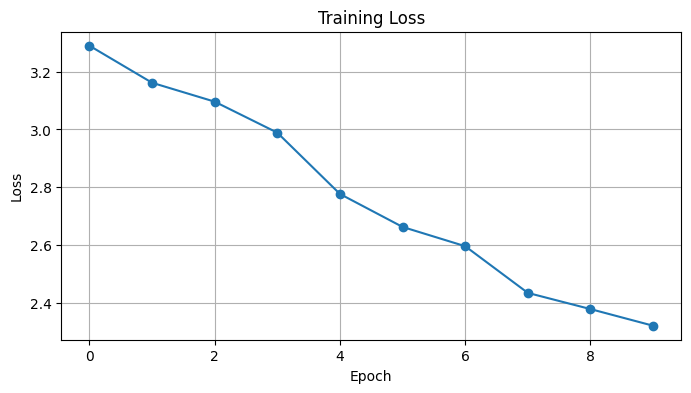

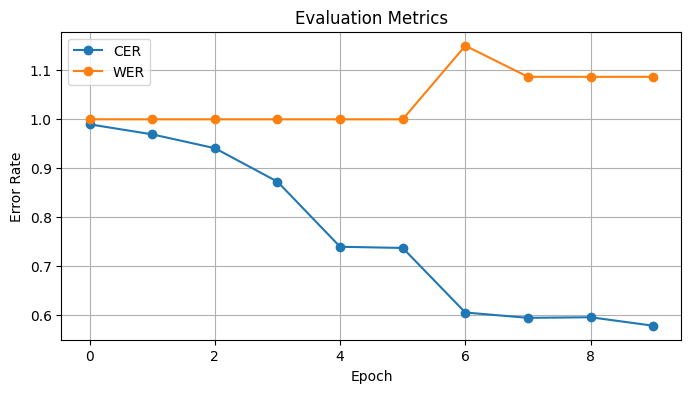

In [15]:
# Plot Results
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(cer_history, marker="o", label="CER")
plt.plot(wer_history, marker="o", label="WER")
plt.title("Evaluation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Conclusion

The CRNN-based OCR model demonstrated consistent learning behavior, with decreasing training loss and improved Character Error Rate (CER). 
While the model struggled with full word-level accuracy (high WER), it successfully captured partial character patterns, 
showing the effectiveness of the approach for this task.